In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys

sys.path.insert(0, "../experiments")

from cascade_utils import extract_batch_arrays, load_results_from_clearml

In [4]:
TASK_ID = "23b9e63359e54a2cbe16d40191b6c052"
results = load_results_from_clearml(TASK_ID)
d = extract_batch_arrays(results)

print(f"Batches: {d['n_batches']}, batch size: {d['batch_size']}")
print(f"Threshold: {d['threshold']}")
print(f"Test set: {len(d['probe_scores'])} examples")

/storage/ceph/usr/k23141813/vrcp_proj/reliable-llm-monitoring/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Batches: 47, batch size: 64
Threshold: 0.85
Test set: 2984 examples


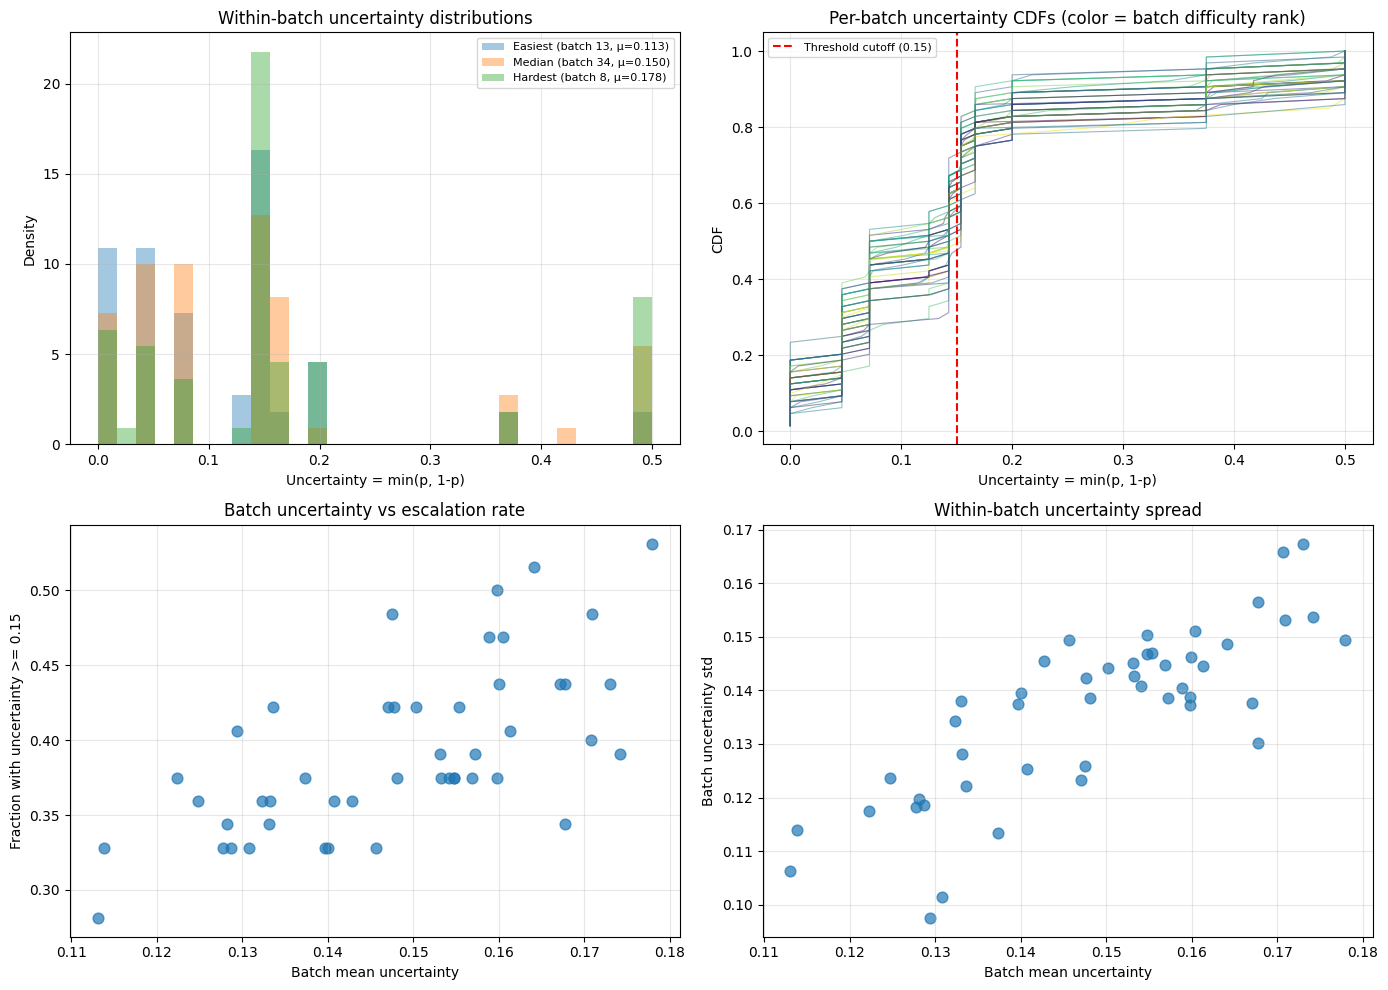

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Within-batch uncertainty distributions: are batches actually different?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overlay uncertainty histograms for a few batches (easiest, hardest, median)
ax = axes[0, 0]
order = np.argsort(d["probe_uncertainty_mean"])
pick = {"Easiest": order[0], "Median": order[len(order) // 2], "Hardest": order[-1]}
bins = np.linspace(0, 0.5, 30)
for label, idx in pick.items():
    ax.hist(
        d["batch_uncertainty"][idx],
        bins=bins,
        alpha=0.4,
        label=f"{label} (batch {idx}, μ={d['probe_uncertainty_mean'][idx]:.3f})",
        density=True,
    )
ax.set_xlabel("Uncertainty = min(p, 1-p)")
ax.set_ylabel("Density")
ax.set_title("Within-batch uncertainty distributions")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 2. All batches: uncertainty CDFs overlaid
ax = axes[0, 1]
for i in order:
    unc = np.sort(d["batch_uncertainty"][i])
    cdf = np.arange(1, len(unc) + 1) / len(unc)
    color = plt.cm.viridis(i / d["n_batches"])
    ax.plot(unc, cdf, color=color, alpha=0.5, linewidth=0.8)
if d["threshold"] is not None:
    ax.axvline(1 - d["threshold"], color="red", linestyle="--", label=f"Threshold cutoff ({1 - d['threshold']:.2f})")
ax.set_xlabel("Uncertainty = min(p, 1-p)")
ax.set_ylabel("CDF")
ax.set_title("Per-batch uncertainty CDFs (color = batch difficulty rank)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 3. Fraction of examples above threshold per batch vs batch mean uncertainty
ax = axes[1, 0]
if d["threshold"] is not None:
    cutoff = 1 - d["threshold"]
    frac_above = np.array([np.mean(unc >= cutoff) for unc in d["batch_uncertainty"]])
    ax.scatter(d["probe_uncertainty_mean"], frac_above, alpha=0.7, s=60)
    ax.set_xlabel("Batch mean uncertainty")
    ax.set_ylabel(f"Fraction with uncertainty >= {cutoff:.2f}")
    ax.set_title("Batch uncertainty vs escalation rate")
    ax.grid(alpha=0.3)

# 4. Within-batch uncertainty spread (std) vs mean
ax = axes[1, 1]
ax.scatter(d["probe_uncertainty_mean"], d["probe_uncertainty_std"], alpha=0.7, s=60)
ax.set_xlabel("Batch mean uncertainty")
ax.set_ylabel("Batch uncertainty std")
ax.set_title("Within-batch uncertainty spread")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Key question: does within-batch uncertainty distribution differ meaningfully,
# or is it just sampling noise from the same global distribution?

from scipy import stats

# KS test: compare each batch's uncertainty distribution to the global distribution
global_uncertainty = np.minimum(d["probe_scores"], 1 - d["probe_scores"])

ks_stats = []
ks_pvals = []
for i in range(d["n_batches"]):
    stat, pval = stats.ks_2samp(d["batch_uncertainty"][i], global_uncertainty)
    ks_stats.append(stat)
    ks_pvals.append(pval)

ks_stats = np.array(ks_stats)
ks_pvals = np.array(ks_pvals)

print(f"KS test (batch vs global distribution):")
print(f"  Significant (p < 0.05): {(ks_pvals < 0.05).sum()}/{d['n_batches']} batches")
print(f"  KS statistic: mean={ks_stats.mean():.4f}, max={ks_stats.max():.4f}")
print()

# How much of the batch-to-batch variation in uncertainty is just sampling noise?
# Compare observed variance of batch means to expected variance under i.i.d. sampling
observed_var = d["probe_uncertainty_mean"].var()
# Under i.i.d., variance of batch means = global_var / batch_size
expected_var_iid = global_uncertainty.var() / d["batch_size"]
ratio = observed_var / expected_var_iid

print(f"Batch mean uncertainty: observed var = {observed_var:.6f}")
print(f"Expected var under i.i.d. = {expected_var_iid:.6f}")
print(f"Ratio (observed/expected) = {ratio:.3f}")
print(f"  Ratio ≈ 1 means batches are just random samples (no real difficulty variation)")
print(f"  Ratio >> 1 would mean genuine batch-level structure")

KS test (batch vs global distribution):
  Significant (p < 0.05): 1/47 batches
  KS statistic: mean=0.0862, max=0.1816

Batch mean uncertainty: observed var = 0.000267
Expected var under i.i.d. = 0.000297
Ratio (observed/expected) = 0.901
  Ratio ≈ 1 means batches are just random samples (no real difficulty variation)
  Ratio >> 1 would mean genuine batch-level structure


In [10]:
from pathlib import Path

from reliable_monitoring.cascade import select_fixed_budget_rate, select_fixed_threshold

FIXED_RATE = results.mean_budget_cost  # match adaptive's overall budget
FIG_DIR = Path("../figures/batch_delegation")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def plot_batch_delegation(batch_idx: int, d: dict, fixed_rate: float = FIXED_RATE, save_dir: Path | None = FIG_DIR):
    """Show uncertainty distribution and delegation regions for a single batch."""
    probe_scores = d["batch_probe_scores"][batch_idx]
    baseline_scores = d["batch_baseline_scores"][batch_idx]
    labels = d["batch_labels"][batch_idx]
    threshold = d["threshold"]
    n = len(probe_scores)

    uncertainty = np.minimum(probe_scores, 1 - probe_scores)

    # Which examples each method delegates
    adaptive_mask = select_fixed_threshold(probe_scores, threshold=threshold)
    fixed_mask = select_fixed_budget_rate(probe_scores, rate=fixed_rate)

    # Correctness
    probe_preds = (probe_scores >= 0.5).astype(int)
    baseline_preds = (baseline_scores >= 0.5).astype(int)
    probe_correct = probe_preds == labels

    # Cascade outcomes per method (using replace merge)
    def cascade_acc(mask):
        final_preds = np.where(mask, baseline_preds, probe_preds)
        return (final_preds == labels).mean()

    adpt_acc = cascade_acc(adaptive_mask)
    fixd_acc = cascade_acc(fixed_mask)
    probe_acc = probe_correct.mean()

    # Sort by probe score for plotting
    order = np.argsort(probe_scores)
    sorted_scores = probe_scores[order]
    sorted_correct = probe_correct[order]
    sorted_adaptive = adaptive_mask[order]
    sorted_fixed = fixed_mask[order]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(
        f"Batch {batch_idx} — "
        f"Probe acc: {probe_acc:.3f} | Adaptive acc: {adpt_acc:.3f} (budget {adaptive_mask.mean():.2f}) | "
        f"Fixed acc: {fixd_acc:.3f} (budget {fixed_mask.mean():.2f})",
        fontsize=11,
        fontweight="bold",
    )

    # Panel 1: Probe scores sorted, colored by correct/wrong, with delegation bands
    ax = axes[0]
    colors = ["forestgreen" if c else "crimson" for c in sorted_correct]
    ax.bar(range(n), sorted_scores, color=colors, alpha=0.6, width=1.0, edgecolor="none")
    ax.axhline(0.5, color="black", linestyle="-", linewidth=0.5, alpha=0.5)
    if threshold is not None:
        ax.axhline(threshold, color="orange", linestyle="--", linewidth=1.5, label=f"Threshold ({threshold})")
        ax.axhline(1 - threshold, color="orange", linestyle="--", linewidth=1.5)
        ax.axhspan(1 - threshold, threshold, alpha=0.08, color="orange", label="Adaptive band")
    ax.set_xlabel("Example (sorted by probe score)")
    ax.set_ylabel("Probe score")
    ax.set_title("Probe scores (green=correct, red=wrong)")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_ylim([0, 1])
    ax.grid(axis="y", alpha=0.3)

    # Panel 2: Side-by-side comparison of which examples each method delegates
    ax = axes[1]
    adaptive_colors = np.where(sorted_adaptive, np.where(sorted_correct, "lightblue", "salmon"), "whitesmoke")
    fixed_colors = np.where(sorted_fixed, np.where(sorted_correct, "lightblue", "salmon"), "whitesmoke")

    for i in range(n):
        ax.bar(i, 0.45, bottom=0.55, color=adaptive_colors[i], edgecolor="gray", linewidth=0.2, width=1.0)
        ax.bar(i, 0.45, bottom=0.0, color=fixed_colors[i], edgecolor="gray", linewidth=0.2, width=1.0)

    ax.set_yticks([0.225, 0.775])
    ax.set_yticklabels(["Fixed", "Adaptive"])
    ax.set_xlabel("Example (sorted by probe score)")
    ax.set_title("Delegated examples (blue=correct, red=wrong, gray=not delegated)")
    ax.set_xlim([-0.5, n - 0.5])

    # Panel 3: Uncertainty histogram with cutoffs
    ax = axes[2]
    bins = np.linspace(0, 0.5, 25)
    ax.hist(uncertainty, bins=bins, alpha=0.5, color="steelblue", edgecolor="black", label="All examples")
    ax.hist(uncertainty[~probe_correct], bins=bins, alpha=0.6, color="crimson", edgecolor="black", label="Probe errors")
    if threshold is not None:
        cutoff = 1 - threshold
        ax.axvline(cutoff, color="orange", linewidth=2, linestyle="--", label=f"Adaptive cutoff ({cutoff:.2f})")
    fixed_uncertainties = uncertainty[fixed_mask]
    if len(fixed_uncertainties) > 0:
        fixed_cutoff = fixed_uncertainties.min()
        ax.axvline(
            fixed_cutoff,
            color="purple",
            linewidth=2,
            linestyle="--",
            label=f"Fixed effective cutoff ({fixed_cutoff:.3f})",
        )
    ax.set_xlabel("Uncertainty = min(p, 1-p)")
    ax.set_ylabel("Count")
    ax.set_title("Uncertainty distribution")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    if save_dir is not None:
        path = save_dir / f"batch_{batch_idx:03d}.png"
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  Saved {path}")

    plt.show()

    # Print summary
    only_adaptive = adaptive_mask & ~fixed_mask
    only_fixed = fixed_mask & ~adaptive_mask
    both = adaptive_mask & fixed_mask
    print(f"  Delegated: adaptive={adaptive_mask.sum()}, fixed={fixed_mask.sum()}, overlap={both.sum()}")
    print(f"  Only adaptive: {only_adaptive.sum()} (of which {(only_adaptive & ~probe_correct).sum()} probe errors)")
    print(f"  Only fixed:    {only_fixed.sum()} (of which {(only_fixed & ~probe_correct).sum()} probe errors)")
    print()

=== 3 EASIEST BATCHES ===

  Saved ../figures/batch_delegation/batch_013.png


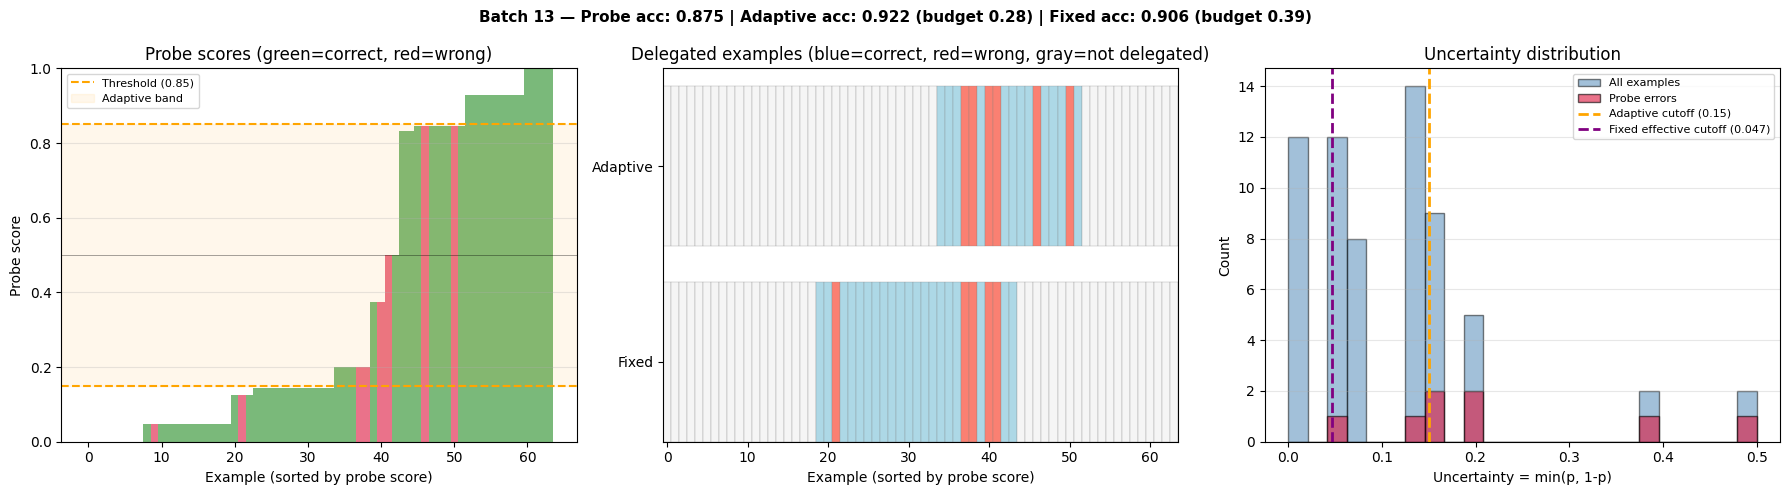

  Delegated: adaptive=18, fixed=25, overlap=10
  Only adaptive: 8 (of which 2 probe errors)
  Only fixed:    15 (of which 1 probe errors)

  Saved ../figures/batch_delegation/batch_017.png


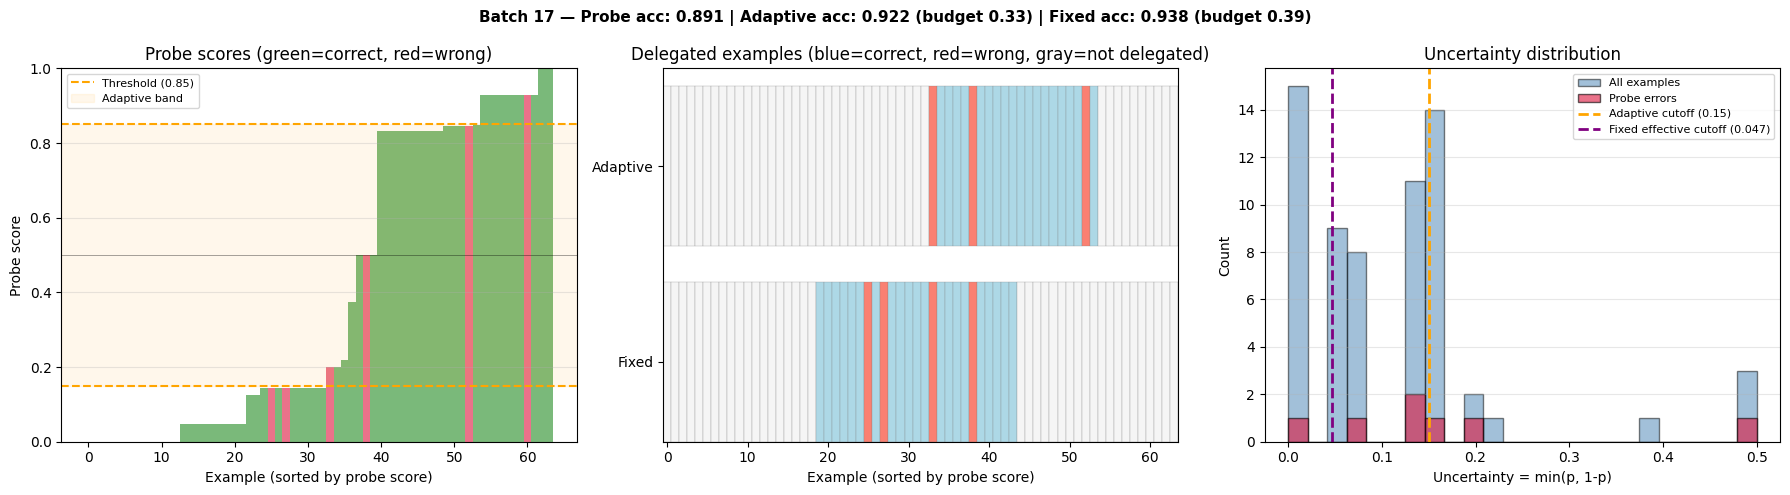

  Delegated: adaptive=21, fixed=25, overlap=11
  Only adaptive: 10 (of which 1 probe errors)
  Only fixed:    14 (of which 2 probe errors)

  Saved ../figures/batch_delegation/batch_025.png


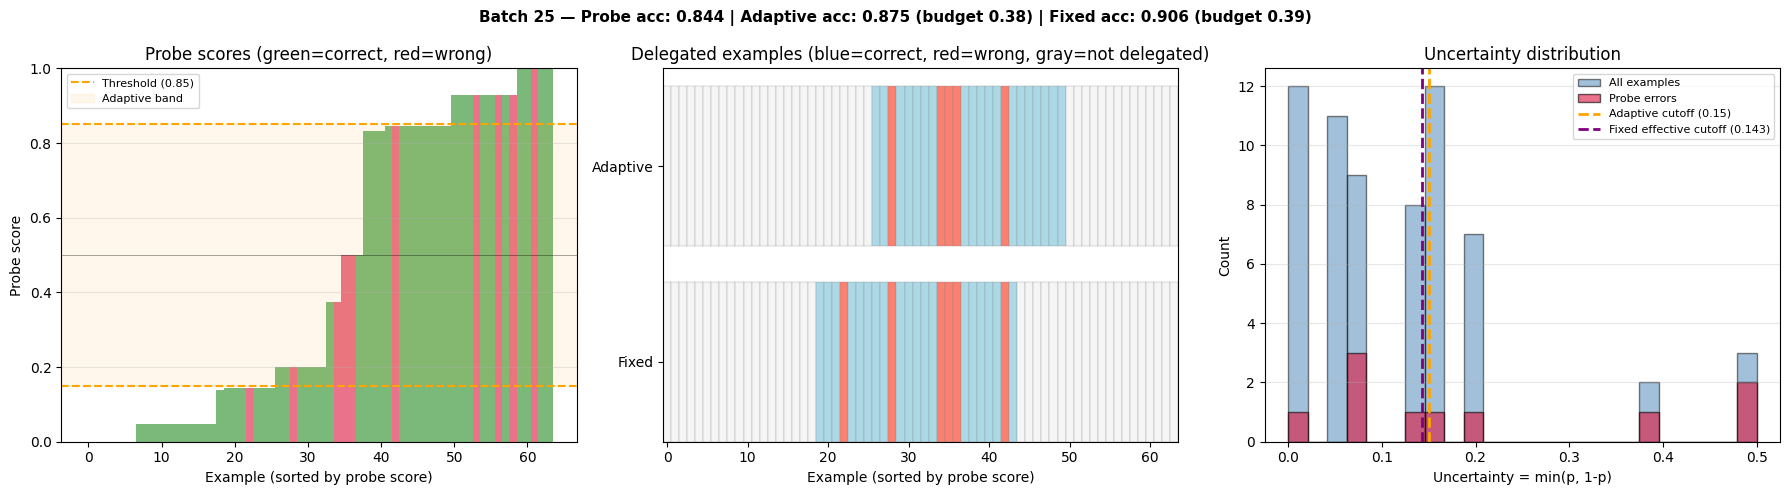

  Delegated: adaptive=24, fixed=25, overlap=18
  Only adaptive: 6 (of which 0 probe errors)
  Only fixed:    7 (of which 1 probe errors)



In [11]:
order = np.argsort(d["probe_uncertainty_mean"])

print("=== 3 EASIEST BATCHES ===\n")
for idx in order[:3]:
    plot_batch_delegation(idx, d)

=== 3 HARDEST BATCHES ===

  Saved ../figures/batch_delegation/batch_019.png


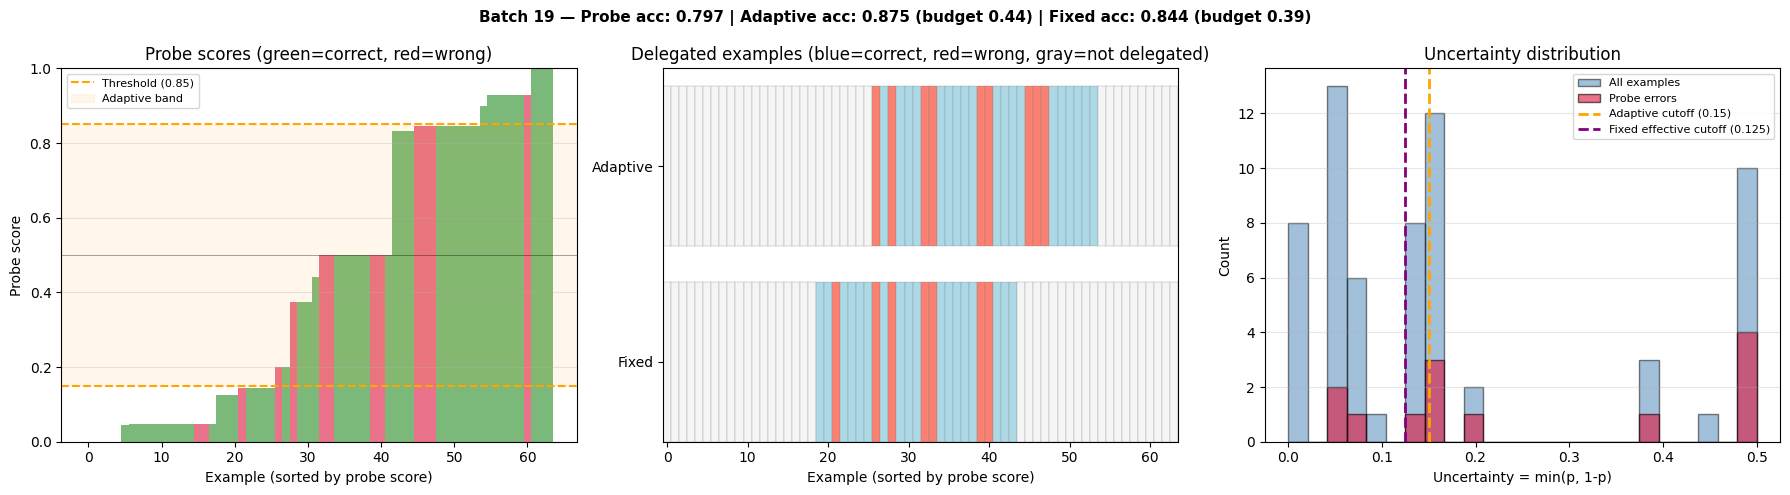

  Delegated: adaptive=28, fixed=25, overlap=18
  Only adaptive: 10 (of which 3 probe errors)
  Only fixed:    7 (of which 1 probe errors)

  Saved ../figures/batch_delegation/batch_020.png


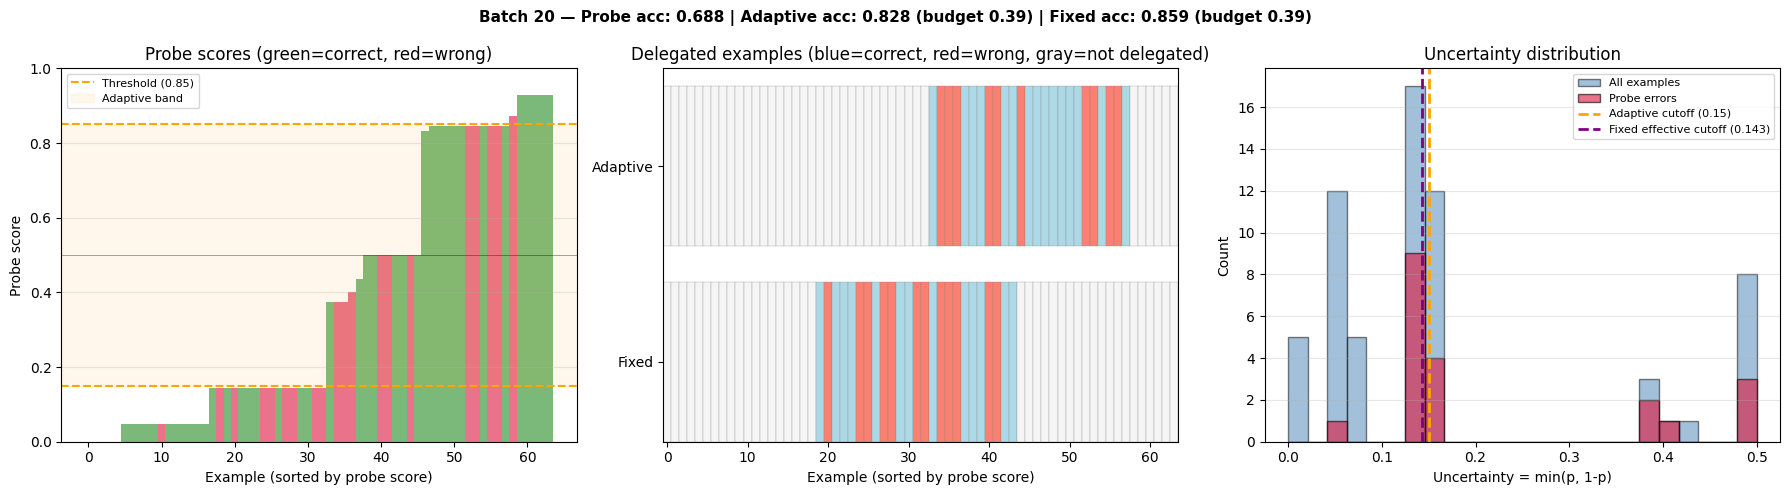

  Delegated: adaptive=25, fixed=25, overlap=11
  Only adaptive: 14 (of which 5 probe errors)
  Only fixed:    14 (of which 7 probe errors)

  Saved ../figures/batch_delegation/batch_008.png


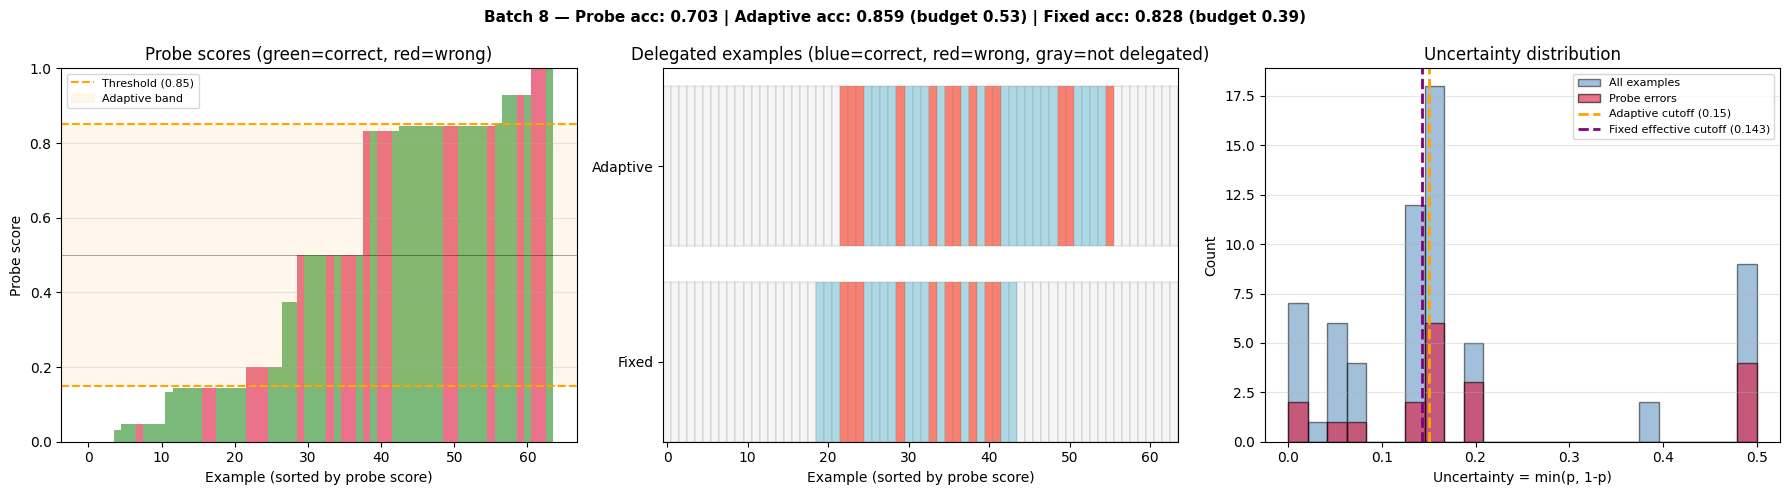

  Delegated: adaptive=34, fixed=25, overlap=22
  Only adaptive: 12 (of which 3 probe errors)
  Only fixed:    3 (of which 0 probe errors)



In [12]:
print("=== 3 HARDEST BATCHES ===\n")
for idx in order[-3:]:
    plot_batch_delegation(idx, d)

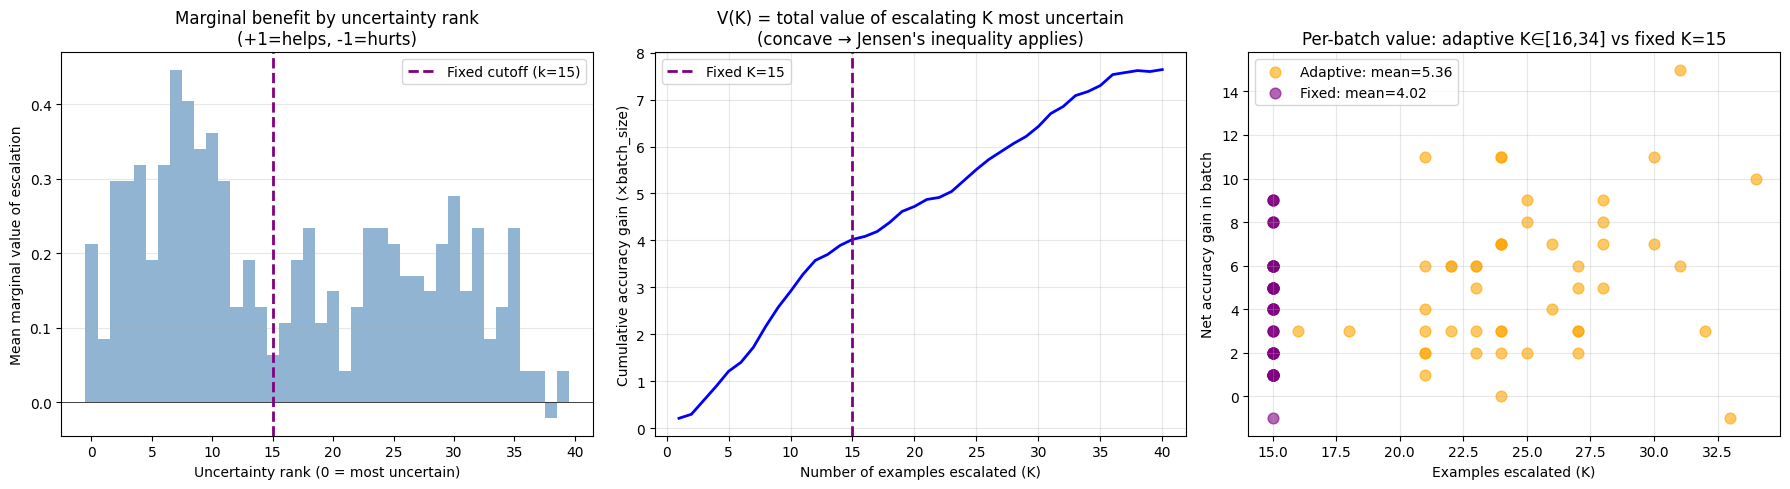


Adaptive K per batch: mean=25.0, std=3.8, range=[16, 34]
Fixed K per batch: 15

Mean net corrections per batch:
  Adaptive: 5.362
  Fixed:    4.021
  Gap:      -1.340 (Jensen's gap)

V(K) concavity check: V''(K) should be ≤ 0
  Mean second difference of marginal: -0.0044 (negative = concave ✓)


In [15]:
# === Jensen's inequality explanation for why adaptive is WORSE ===
#
# Both methods rank by the same signal (probe uncertainty).
# Fixed: always selects top-K most uncertain per batch (K constant).
# Adaptive: selects all with uncertainty > tau (variable K_b per batch).
#
# Define V(K) = total accuracy gain from escalating K most uncertain examples.
# If marginal benefit decreases with rank (most uncertain benefit most),
# then V is concave. By Jensen's: E[V(K_b)] <= V(E[K_b]) = V(K).
# -> Constant allocation ALWAYS beats variable allocation for i.i.d. data.

from reliable_monitoring.cascade import select_fixed_budget_rate

# 1. Compute the marginal value curve: for each uncertainty rank k,
#    what's the average accuracy gain from escalating that example?
all_marginal_values = []
batch_sizes = []

for batch_idx in range(d["n_batches"]):
    ps = d["batch_probe_scores"][batch_idx]
    bs = d["batch_baseline_scores"][batch_idx]
    labels = d["batch_labels"][batch_idx]

    uncertainty = np.minimum(ps, 1 - ps)
    # Sort by uncertainty descending (most uncertain first)
    order = np.argsort(-uncertainty)

    probe_preds = (ps >= 0.5).astype(int)
    baseline_preds = (bs >= 0.5).astype(int)
    probe_correct = probe_preds == labels
    baseline_correct = baseline_preds == labels

    # Marginal value of escalating rank-k example:
    # +1 if baseline correct & probe wrong, -1 if probe correct & baseline wrong, 0 otherwise
    marginal = np.zeros(len(ps))
    for rank, idx in enumerate(order):
        if baseline_correct[idx] and not probe_correct[idx]:
            marginal[rank] = 1.0  # escalation helps
        elif probe_correct[idx] and not baseline_correct[idx]:
            marginal[rank] = -1.0  # escalation hurts
        else:
            marginal[rank] = 0.0  # no change

    all_marginal_values.append(marginal)
    batch_sizes.append(len(ps))

# Some runs have slight batch-size variation; align to the smallest batch for aggregation.
min_len = int(np.min(batch_sizes))
all_marginal_values = np.stack([mv[:min_len] for mv in all_marginal_values], axis=0)
mean_marginal = all_marginal_values.mean(axis=0)
cumulative_value = np.cumsum(mean_marginal)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Marginal value by rank
ax = axes[0]
ax.bar(range(len(mean_marginal)), mean_marginal, alpha=0.6, color="steelblue", width=1.0)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Uncertainty rank (0 = most uncertain)")
ax.set_ylabel("Mean marginal value of escalation")
ax.set_title("Marginal benefit by uncertainty rank\n(+1=helps, -1=hurts)")
ax.grid(axis="y", alpha=0.3)

# Mark where fixed rate falls
fixed_k = int(FIXED_RATE * min_len)
ax.axvline(fixed_k, color="purple", linestyle="--", linewidth=2, label=f"Fixed cutoff (k={fixed_k})")
ax.legend()

# Panel 2: Cumulative value V(K) — should be concave
ax = axes[1]
ax.plot(range(1, len(cumulative_value) + 1), cumulative_value, "b-", linewidth=2)
ax.axvline(fixed_k, color="purple", linestyle="--", linewidth=2, label=f"Fixed K={fixed_k}")
ax.set_xlabel("Number of examples escalated (K)")
ax.set_ylabel("Cumulative accuracy gain (×batch_size)")
ax.set_title("V(K) = total value of escalating K most uncertain\n(concave → Jensen's inequality applies)")
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: Jensen's gap — compare V(K_b) across batches to V(K)
ax = axes[2]
threshold = d["threshold"]
adaptive_counts = []
fixed_count = fixed_k

for batch_idx in range(d["n_batches"]):
    ps = d["batch_probe_scores"][batch_idx]
    mask = select_fixed_threshold(ps, threshold=threshold)
    adaptive_counts.append(mask.sum())

adaptive_counts = np.array(adaptive_counts)

# Per-batch V(K_b) for adaptive
batch_values_adaptive = []
batch_values_fixed = []
for batch_idx in range(d["n_batches"]):
    mv = all_marginal_values[batch_idx]
    kb = min(adaptive_counts[batch_idx], min_len)
    batch_values_adaptive.append(mv[:kb].sum() if kb > 0 else 0)
    batch_values_fixed.append(mv[:fixed_count].sum())

batch_values_adaptive = np.array(batch_values_adaptive)
batch_values_fixed = np.array(batch_values_fixed)

ax.scatter(
    adaptive_counts,
    batch_values_adaptive,
    alpha=0.6,
    s=60,
    label=f"Adaptive: mean={batch_values_adaptive.mean():.2f}",
    color="orange",
)
ax.scatter(
    np.full(d["n_batches"], fixed_count),
    batch_values_fixed,
    alpha=0.6,
    s=60,
    label=f"Fixed: mean={batch_values_fixed.mean():.2f}",
    color="purple",
)
ax.set_xlabel("Examples escalated (K)")
ax.set_ylabel("Net accuracy gain in batch")
ax.set_title(f"Per-batch value: adaptive K∈[{adaptive_counts.min()},{adaptive_counts.max()}] vs fixed K={fixed_count}")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / "jensens_inequality.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"\nAdaptive K per batch: mean={adaptive_counts.mean():.1f}, std={adaptive_counts.std():.1f}, range=[{adaptive_counts.min()}, {adaptive_counts.max()}]"
)
print(f"Fixed K per batch: {fixed_count}")
print(f"\nMean net corrections per batch:")
print(f"  Adaptive: {batch_values_adaptive.mean():.3f}")
print(f"  Fixed:    {batch_values_fixed.mean():.3f}")
print(f"  Gap:      {batch_values_fixed.mean() - batch_values_adaptive.mean():.3f} (Jensen's gap)")
print(f"\nV(K) concavity check: V''(K) should be ≤ 0")
second_diff = np.diff(mean_marginal)
print(
    f"  Mean second difference of marginal: {second_diff.mean():.4f} (negative = concave ✓)"
    if second_diff.mean() < 0
    else f"  Mean second difference: {second_diff.mean():.4f}"
)